# Model 2: Position embedding, layernorm, tied output, temperature

In [1]:
import requests
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

In [2]:
# GPT-4's tokenizer
import tiktoken
tokenizer = tiktoken.get_encoding('cl100k_base')

## Hyperparameters

In [3]:
# data params
seq_len = 8 # aka context window
stride = 2

# model params
embed_dim = 2**6 # 64

# training params
batch_size = 5

## Get data

In [4]:
# tokenize the text
# note that we need torch tensors!
text = requests.get('https://www.gutenberg.org/files/35/35-0.txt').text
tmTokens = torch.tensor( tokenizer.encode(text) )
len(tmTokens)

43053

## DataLoader

In [5]:
# create a class for a dataset 
# (note: batching is done by the DataLoader, not in the dataset)
class tokenDataset(Dataset):
    def __init__(self, tokens, seq_len=8, stride=4):
        # initialize
        self.inputs = []
        self.targets = []

        # overlapping sequences of seq_len
        for i in range(0, len(tokens)-seq_len, stride):
            self.inputs.append(tokens[i: i+seq_len])
            self.targets.append(tokens[i+1: i+1+seq_len])
    
    def __len__(self):
        return len(self.inputs)
    
    def __getitem__(self, index):
        return self.inputs[index], self.targets[index]


# create an instance
token_dataset = tokenDataset(tmTokens, seq_len, stride)

token_dataset[4]

(tensor([ 9745,    38,   469, 37725,   220,  1758, 17601,   881]),
 tensor([   38,   469, 37725,   220,  1758, 17601,   881,  8731]))

## The model

In [6]:
class Model(nn.Module):
    def __init__(self):
        super().__init__()

        # embeddings matrices
        self.embedding = nn.Embedding(tokenizer.n_vocab, embed_dim)
        self.positions = nn.Embedding(seq_len, embed_dim)

        # nonlinearity and layernorm
        self.gelu = nn.GELU()
        self.layernorm = nn.LayerNorm(embed_dim)

        # the final output layer is tied to the token embeddings
        self.finalLinear = nn.Linear(embed_dim, tokenizer.n_vocab)
        self.finalLinear.weigh = nn.Parameter(self.embedding.weight)
    
    def forward(self, tokx):
        # create the token+position embedding
        token_embed = self.embedding(tokx)
        posit_embed = self.positions(torch.arange(tokx.shape[-1])) # [numtokens, embedding_dims]

        # their sum is the output of the embeddings (the addition will broadcast for batch>1)
        x = token_embed + posit_embed # [batch, numtokens, embedding_dims]

        # layernorm before the linear layer
        x = self.layernorm(x)

        # forward pass
        x = self.gelu(x) # note: full GPT models don't have gelu before the final unembeddings
        x = self.finalLinear(x) / np.sqrt(embed_dim)

        return x
    
    def generate(self, tokx, temperature=1, n_new_tokens=50):
        # tokx is [batch, tokens]
        for _ in range(n_new_tokens):
            # get predictions, but only from the past seq_len tokens
            x = self(tokx[:,-seq_len:]) # [batch, seq_len, n_vocab]

            # extract the final token to predict the next
            x = x[:, -1, :] # [batch, n_vocab]

            # apply softmax to get probability values over all tokens in the vocab - with temperature
            probs = F.softmax(x / temperature, dim=-1) # [batch, n_vocab]

            # probabilistically sample from the distribution
            tokx_next = torch.multinomial(probs, num_samples=1) # [batch, 1]

            # append
            tokx = torch.cat((tokx, tokx_next), dim=1) # [batch, (tokens+1)]
        
        return tokx

In [7]:
m = Model()
X, y = token_dataset[4]
out = m(X)

print(X.shape)
print(y.shape)
print(out.shape)

torch.Size([8])
torch.Size([8])
torch.Size([8, 100277])


In [9]:
m

Model(
  (embedding): Embedding(100277, 64)
  (positions): Embedding(8, 64)
  (gelu): GELU(approximate='none')
  (layernorm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  (finalLinear): Linear(in_features=64, out_features=100277, bias=True)
)

In [8]:
print(f'Expected loss for random weights: {-np.log(1/tokenizer.n_vocab):.3f}')
print(f'Observed mean log-softmax output: {torch.mean(-F.log_softmax(out.detach(),dim=-1)):.3f}')
print(f'Cross-entropy loss from pytorch:  {F.cross_entropy(out.view(-1, out.shape[-1]), y.view(-1)):.3f}')

Expected loss for random weights: 11.516
Observed mean log-softmax output: 11.517
Cross-entropy loss from pytorch:  11.491


## Demo of position+token embeddings

In [10]:
# broadcasting the token+position embeddings in small matrices
T = torch.ones(2,3,4) # [batch, numtokens, embedding_dims]
P = torch.arange(4)

print(f'Token embeddings matrix ({T.shape}):')
print(T)

print(f'\nPosition embeddings matrix ({P.shape}):')
print(P)

print(f'\nTheir sum: ({(T+P).shape}):')
print(T+P)

Token embeddings matrix (torch.Size([2, 3, 4])):
tensor([[[1., 1., 1., 1.],
         [1., 1., 1., 1.],
         [1., 1., 1., 1.]],

        [[1., 1., 1., 1.],
         [1., 1., 1., 1.],
         [1., 1., 1., 1.]]])

Position embeddings matrix (torch.Size([4])):
tensor([0, 1, 2, 3])

Their sum: (torch.Size([2, 3, 4])):
tensor([[[1., 2., 3., 4.],
         [1., 2., 3., 4.],
         [1., 2., 3., 4.]],

        [[1., 2., 3., 4.],
         [1., 2., 3., 4.],
         [1., 2., 3., 4.]]])


In [11]:
# again using real weights from the model
P = m.positions(torch.arange(seq_len))
T = m.embedding(X)

print(f'Token embeddings matrix ({T.shape})')
print(f'\nPosition embeddings matrix ({P.shape})')
print(f'\nTheir sum: ({(T+P).shape})')

Token embeddings matrix (torch.Size([8, 64]))

Position embeddings matrix (torch.Size([8, 64]))

Their sum: (torch.Size([8, 64]))


## Visualizing the model output

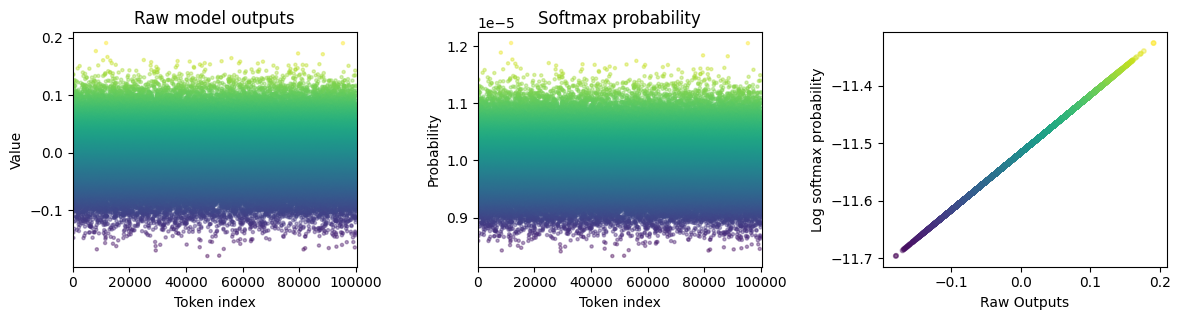

In [12]:
# visualize the softmax output
out = m(X)
final = out[-1, :].detach()
softmax_final = torch.exp(final) / torch.exp(final).sum()

# create a figure
_, axs = plt.subplots(1,3, figsize=(12,3.3))

# show the logits (raw logit coloring throughout)
axs[0].scatter(range(len(final)), final, s=5, marker='o', c=final, alpha=.4)
axs[0].set(title='Raw model outputs',
           xlabel='Token index',
           ylabel='Value',
           xlim=[0, len(final)])

# the softmaxified logits
axs[1].scatter(range(len(softmax_final)), softmax_final, s=5, marker='o', c=final, alpha=.4)
axs[1].set(title='Softmax probability',
           xlabel='Token index',
           ylabel='Probability',
           xlim=[0, len(softmax_final)])

# their relation
axs[2].scatter(final, torch.log(softmax_final), s=10, marker='o', c=final, alpha=.4)
axs[2].set(xlabel='Raw Outputs', ylabel='Log softmax probability')

plt.tight_layout()
plt.show()

## Generate text in batches

In [13]:
# also need a dataloader
dataloader = DataLoader(
    token_dataset,
    batch_size=batch_size,
    shuffle=True,
    drop_last=True
)

# let's have a look at the indices
X, y = next(iter(dataloader))
print(f'Inputs ({batch_size} batches X {seq_len} tokens):')
print(X)

Inputs (5 batches X 8 tokens):
tensor([[  757,   319,   412,   315,   279, 27394, 18304, 14305],
        [   11,  1578,    11,   922,   279,  4212, 13257,    25],
        [73082, 18304, 10378,  2643,   617,   390,   708,   839],
        [  389,   279,  3766, 11879,    13,  3092,  3197,   574],
        [ 4338, 99567,    26,   369,   279,  7160,  1047, 59477]])


In [14]:
# get model outputs (logits)
out = m(X)
print(out.shape) # batch X tokens X vocab
print(out)

torch.Size([5, 8, 100277])
tensor([[[ 5.4916e-03,  8.2565e-03, -8.2940e-03,  ..., -3.6008e-02,
          -2.3987e-02, -2.4172e-02],
         [-7.3359e-02, -9.7388e-02,  1.1610e-01,  ..., -8.5809e-02,
          -4.0158e-02,  6.6634e-02],
         [ 1.9392e-02, -3.6506e-02,  7.1689e-02,  ..., -3.0460e-02,
           2.1056e-02,  6.9894e-02],
         ...,
         [ 6.0019e-03, -6.5397e-03,  2.3452e-02,  ..., -8.0995e-02,
           5.6325e-02,  7.0424e-03],
         [-1.1224e-01, -1.1459e-03,  1.0697e-02,  ..., -1.4454e-02,
          -2.6912e-02,  5.4420e-02],
         [ 1.5748e-02, -2.0683e-02,  4.0266e-02,  ..., -1.5800e-03,
          -1.2346e-02,  4.6092e-02]],

        [[-2.7233e-03, -1.6160e-02,  8.8842e-02,  ..., -2.2337e-02,
           2.6110e-02, -2.3620e-02],
         [-8.7084e-06, -6.3270e-03,  3.8285e-02,  ..., -5.2128e-02,
           9.7052e-02,  1.0201e-01],
         [ 2.9299e-02, -3.7496e-02,  8.6521e-02,  ..., -2.3951e-02,
           5.2383e-02,  3.1477e-02],
         ...

In [17]:
# generate some data
gen_tokens = m.generate(X, temperature=1.3, n_new_tokens=8)
print(gen_tokens.shape) # batch X (tokens+n_new_tokens)

torch.Size([5, 16])


In [18]:
# repeat multiplt times for the same starting point
for batchtok in gen_tokens:
    print('\n--- NEXT SAMPLE: ---\n')
    print(tokenizer.decode(batchtok.tolist()))


--- NEXT SAMPLE: ---

 me
out of the darkness.

“The distinctive Gdk Labor_clicked ajoutTRGLcg commuting

--- NEXT SAMPLE: ---

, again, about the Time Machine: Mom nervexpenses Bene_open NBC女.GUI

--- NEXT SAMPLE: ---

 dismay.

“I might have consoled="? inspect	handleBoNERpis mimetypeagram

--- NEXT SAMPLE: ---

 on the previous journey. My plan wasisActive LDS SQLITE Tambau citrus trendy assignments

--- NEXT SAMPLE: ---

disappeared; for the sun had ceased analyzingategoricalelastic Yuan loaf aktivipeg(session
